<a href="https://colab.research.google.com/github/lilianabs/kaggle-tools/blob/main/Highly_correlated_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧠 1. What “highly correlated” really means

For numerical features, correlation usually refers to the Pearson correlation coefficient:

 - +1 → perfect positive relationship
 - 0 → no linear relationship
 - -1 → perfect negative relationship

👉 Example:

 - height in cm vs height in inches → correlation ≈ 1
 - price vs discount → might be negatively correlated

 📊 2. How to detect correlated features

 Correlation matrix

 What you’re looking for
 - Values close to:
  - +1 or -1 → strong correlation
  - 0.7–0.9 → moderate-high
  - < 0.5 → usually fine

👉 Rule of thumb:

|corr| > 0.8 → investigate

Cases you’ll see
✅ Case A — Redundant features
 - Straight line pattern
 - Example:
  - salary_usd vs salary_mxn

👉 Same information → redundancy

⚠️ Case B — Non-linear relationship
 - Curved pattern
 - Correlation might be low, but relationship exists

👉 Pearson misses this

❌ Case C — Fake correlation
 - Outliers drive correlation
 - Most points unrelated

👉 Dangerous

🧠 4. Why correlation matters (model perspective)

**Linear models (Logistic Regression, Linear Regression)**

👉 Big problem: multicollinearity

 - Coefficients become unstable
 - Model struggles to assign importance
 - Interpretation becomes unreliable

**Tree-based models (Random Forest, XGBoost)**

👉 Less sensitive

 - Can ignore redundant splits
- Still works well

BUT:

- Feature importance gets diluted
- Model becomes harder to interpret

⚠️ 5. Common misconception

❌ “Highly correlated features are bad”

✅ Correct:

Highly correlated features are redundant, not necessarily harmful

🎯 6. What to do when you find correlated features
Step 1 — Ask: Are they the same information?

Example:

 - age vs birth_year

👉 Keep one, drop the other

Step 2 — Keep the more useful version

Criteria:

- Fewer missing values
- Easier to interpret
- More stable (less noise)

Step 3 — Consider combining them

Example:

- height + weight → BMI

👉 Sometimes better than dropping

Step 4 — Let the model decide (tree models)

If using:

- Random Forest
- XGBoost

👉 You can often keep both

But:

- Watch feature importance carefully

Step 5 — For linear models → be stricter

Options:

- Drop one feature
- Use regularization (L1/L2)
- Use PCA (later stage)

🧠 8. The deeper concept (important for your level)

Correlation ≠ usefulness

What you really care about is:

👉 Does this feature add new information about the target?

This connects to:

- Conditional relationships
- Feature importance
- Mutual information

🔥 9. Practical decision framework

When you see correlated features:

Ask these in order:
1. Are they almost identical?
→ Drop one
1. Do they encode slightly different things?
→ Maybe keep both
1. Am I using a linear model?
→ Be stricter
1. Am I using a tree model?
→ You can relax
1. Do I care about interpretability?
→ Reduce correlation

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000

# Base feature
x1 = np.random.normal(0, 1, n)

# Highly correlated with x1
x2 = x1 + np.random.normal(0, 0.1, n)

# Moderately correlated
x3 = x1 + np.random.normal(0, 0.5, n)

# Independent feature
x4 = np.random.normal(0, 1, n)

# Redundant (almost duplicate)
x5 = x1 * 1.0

# Target depends mostly on x1
y = (x1 + np.random.normal(0, 1, n) > 0).astype(int)

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3,
    "x4": x4,
    "x5": x5,
    "target": y
})

In [2]:
df.head()

,x1,x2,x3,x4,x5,target
0,0.496714,0.636650,0.159125,-1.907808,0.496714,0
1,-0.138264,-0.045801,-0.210524,-0.860385,-0.138264,0
2,0.647689,0.653652,0.251479,-0.413606,0.647689,1
3,1.523030,1.458336,1.369049,1.887688,1.523030,1
4,-0.234153,-0.164331,-1.180961,0.556553,-0.234153,0


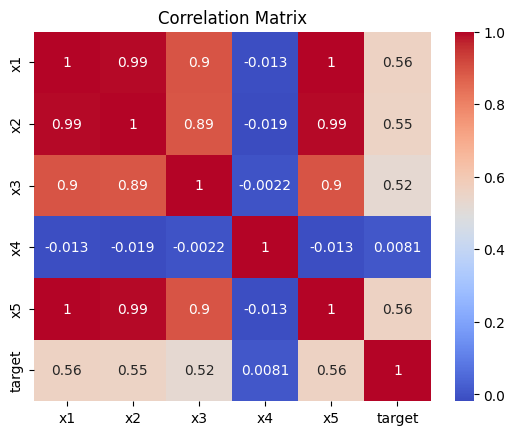

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

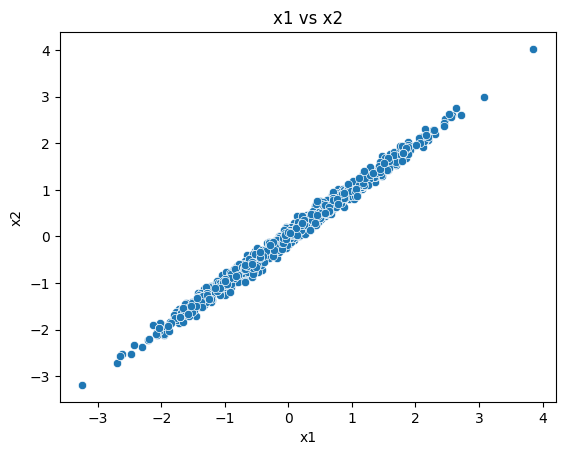

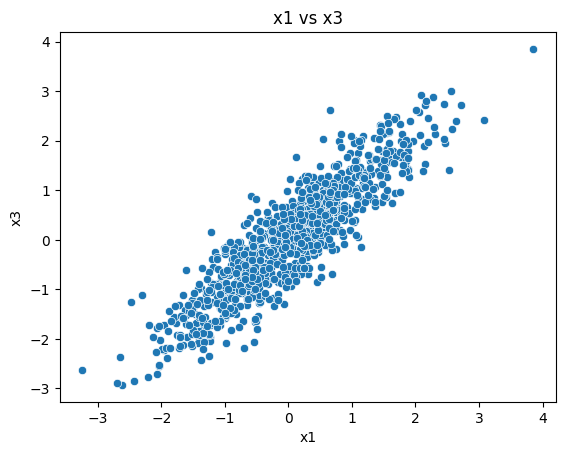

In [4]:
sns.scatterplot(x=df["x1"], y=df["x2"])
plt.title("x1 vs x2")
plt.show()

sns.scatterplot(x=df["x1"], y=df["x3"])
plt.title("x1 vs x3")
plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression

X = df[["x1", "x2", "x3", "x4", "x5"]]
y = df["target"]

model = LogisticRegression()
model.fit(X, y)

list(zip(X.columns, model.coef_[0]))

[('x1', np.float64(0.7230466317085966)),
 ('x2', np.float64(-0.028108791801240554)),
 ('x3', np.float64(0.2809606909071975)),
 ('x4', np.float64(0.0187532897920292)),
 ('x5', np.float64(0.723046631708592))]

🚨 Observe carefully

You’ll likely see:

- Weird coefficients (some very large, some small)
- Signs flipping (+ / - unexpectedly)

👉 This is multicollinearity

Even though:

- x1, x2, x5 all contain the same signal
- The model struggles to distribute importance

In [6]:
X_reduced = df[["x1", "x3", "x4"]]

model2 = LogisticRegression()
model2.fit(X_reduced, y)

list(zip(X_reduced.columns, model2.coef_[0]))

[('x1', np.float64(1.3945134559467778)),
 ('x3', np.float64(0.2969539327464644)),
 ('x4', np.float64(0.018821861196377108))]

✅ Compare

Now:

- Coefficients are more stable
- Interpretation makes sense

👉 Same predictive power, better behavior

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

list(zip(X.columns, rf.feature_importances_))

[('x1', np.float64(0.23232552412875118)),
 ('x2', np.float64(0.21832115902424895)),
 ('x3', np.float64(0.15762764557064685)),
 ('x4', np.float64(0.1522522044307816)),
 ('x5', np.float64(0.23947346684557153))]

🔍 Observe
- x1, x2, x5 will share importance
- Importance gets “split” across correlated features

👉 Tree models don’t break—but interpretation gets messy

In [8]:
rf2 = RandomForestClassifier()
rf2.fit(X_reduced, y)

list(zip(X_reduced.columns, rf2.feature_importances_))

[('x1', np.float64(0.39655130072297123)),
 ('x3', np.float64(0.37210209752278783)),
 ('x4', np.float64(0.23134660175424093))]

✅ Observe
- Importance concentrates on x1
- Much cleaner interpretation

In [9]:
from sklearn.metrics import roc_auc_score

# Full model
preds_full = model.predict_proba(X)[:, 1]
auc_full = roc_auc_score(y, preds_full)

# Reduced model
preds_reduced = model2.predict_proba(X_reduced)[:, 1]
auc_reduced = roc_auc_score(y, preds_reduced)

auc_full, auc_reduced

(np.float64(0.8298389838983898), np.float64(0.8299589958995899))

🎯 Key insight

👉 Performance will be very similar

BUT:

- Simpler model
- More stable coefficients
- Easier to explain

In [11]:
# Automatic correlation filtering
# 👉 This gives you candidates to remove
threshold = 0.9
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
to_drop

['x2', 'x5']

🧠 Step 9 — Build your intuition

After this exercise, you should internalize:

**Case 1 — Perfect / near-perfect correlation**
- Drop one feature
- No information loss

**Case 2 — Moderate correlation**
- Keep both (often useful)
- Especially for tree models

**Case 3 — Independent**
Always keep

🎯 Final mental model

When you see correlated features:

“Am I adding new information, or repeating the same signal?”